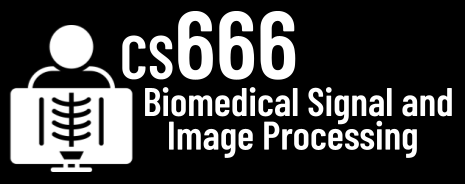
#Assignment 2

In [42]:
# Vrishin Jain

In [43]:
%pylab inline
import os

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['sample']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [44]:
# we will be using the EEG/MEG analysis library MNE
# documentation is available here: https://mne.tools/stable/index.html
!pip install -U mne

In [45]:
import mne # let's import MNE

# .. and the sample dataset
from mne.datasets import sample

# These data were acquired with the Neuromag Vectorview system at
# MGH/HMS/MIT Athinoula A. Martinos Center Biomedical Imaging.
# EEG data from an electrode cap was acquired simultaneously with the MEG.

### EXPERIMENT DESCRIPTION ###
# In this experiment, checkerboard patterns were presented to the subject into
# the left and right visual field, interspersed by tones to the left or right ear.
# The interval between the stimuli was 750 ms. Occasionally a smiley face was
# presented at the center of the visual field. The subject was asked to press a
# key with the right index finger as soon as possible after the appearance of the face.

In [46]:
# and let's load it!
data_path = sample.data_path()
raw = mne.io.read_raw_fif(os.path.join(data_path,'MEG/sample/sample_audvis_raw.fif'))

Opening raw data file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


**Task 1:** Analyze the data. [20 Points]


In [47]:
print(raw)

<Raw | sample_audvis_raw.fif, 376 x 166800 (277.7 s), ~3.2 MiB, data not loaded>


In [48]:
raw.copy().pick_types(eeg=True).info

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


<Info | 19 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: []
 ch_names: EEG 001, EEG 002, EEG 003, EEG 004, EEG 005, EEG 006, EEG 007, ...
 chs: 59 EEG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 59
 proj_id: 1
 proj_name: test
 projs: []
 sfreq: 600.6 Hz
>

In [49]:
# ECG channels =59
#Sampling frequency = 600.61Hz
#Duration = 277.7

**Task 2:** Let's look at some channels! [20 Points]

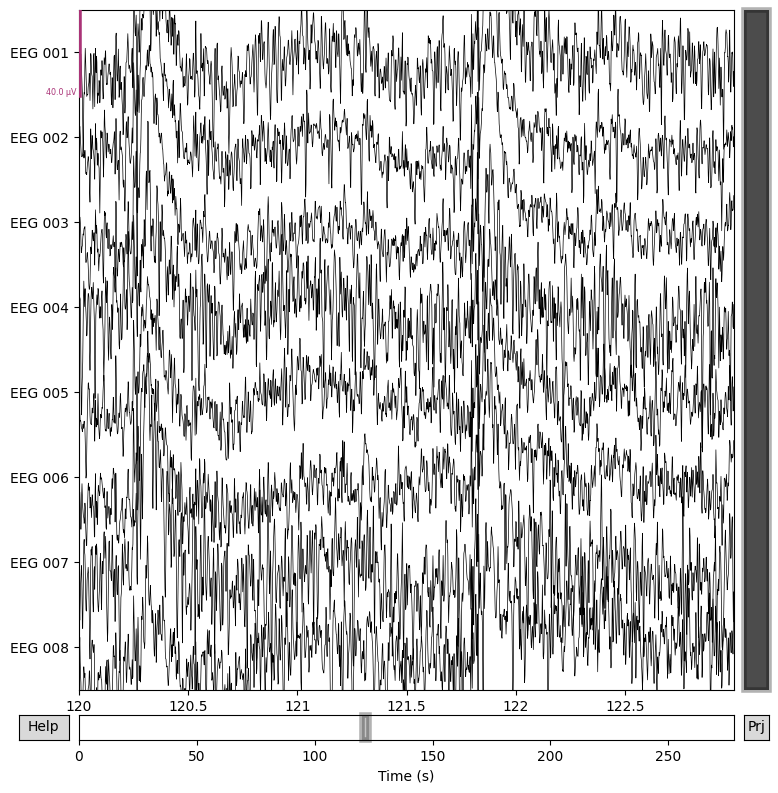

In [50]:
# the code below plots EEG channels 1-8 for 3 seconds after 2 minutes
chs = ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008']
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
ecg1to8 = raw.plot(order=chan_idxs, start=120, duration=3)

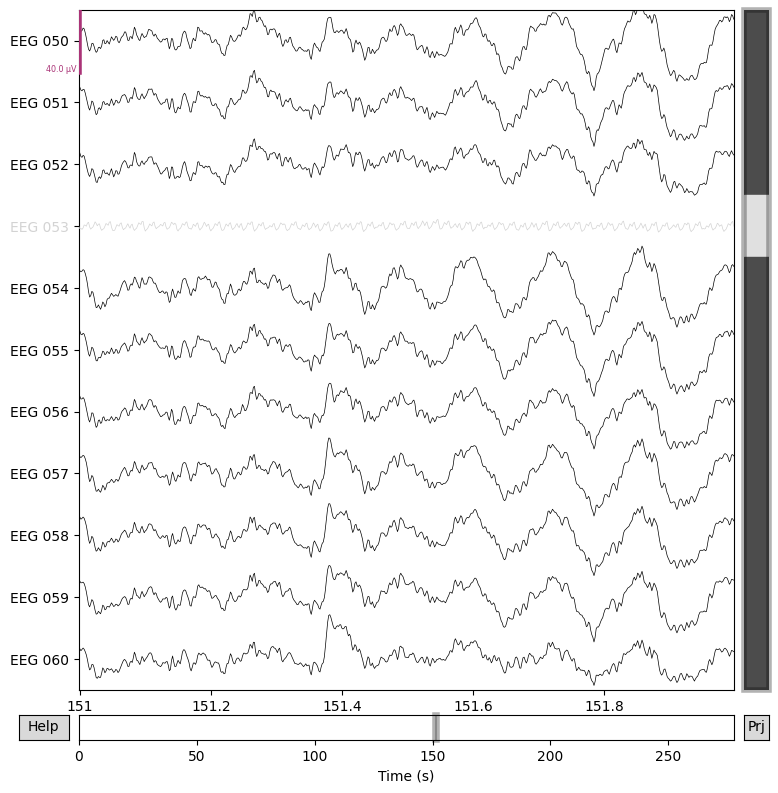

In [51]:
# TODO please plot EEG channels 50-60 for 1 second after 151 seconds.
chs = ['EEG 050', 'EEG 051', 'EEG 052', 'EEG 053', 'EEG 054', 'EEG 055', 'EEG 056', 'EEG 057', 'EEG 058', 'EEG 059', 'EEG 060']
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
ecg1to8 = raw.plot(order=chan_idxs, start=151, duration=1)

In [52]:
import numpy as np

In [53]:
bad_ch = 'EEG 053'
good_ch = 'EEG 051'

bad_data, times = raw.get_data(picks=[bad_ch], return_times = True)
good_data, times = raw.get_data(picks=[good_ch], return_times = True)

bad_data = bad_data[0]
good_data = good_data[0]

bad_max = abs(bad_data).max()
good_max = abs(good_data).max()

print("Bad Channel - ", bad_ch, "max ([X]) - ", bad_max)
print("Bad Channel - ", good_ch, "max ([X]) - ", good_max)
print("Ratio - ", bad_max/good_max)

Bad Channel -  EEG 053 max ([X]) -  6.10056150396332e-05
Bad Channel -  EEG 051 max ([X]) -  0.00018777664413160977
Ratio -  0.32488393496304735


In [54]:
# TODO: Do you see a bad channel? If yes, which one?
# Yes, it is EEG 053

In [55]:
# TODO: Please calculate the maximum value of the bad channel and compare it
# against a good channel. How would you detect a bad channel programmatically?
# The bad and good channels were compared using maximum amplitude; bad channels can be detected programmatically by flagging channels whose amplitude or peak-to-peak values are outliers relative to the rest.

**Task 3:** How long between event and brain activity? [25 Points]

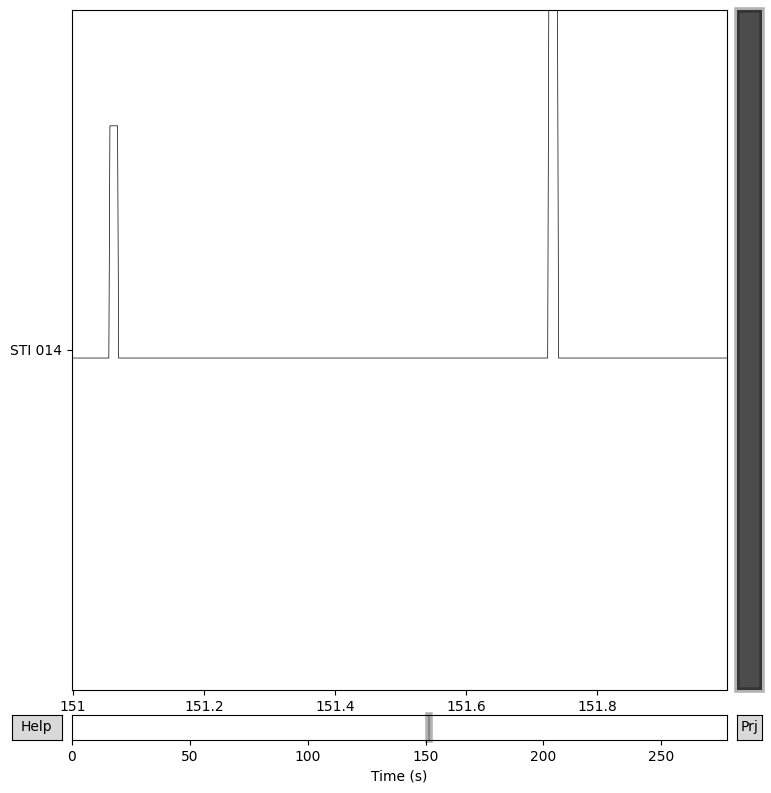

In [56]:
# the following code plots the stimulus channel for the same time
chan_idxs = [raw.ch_names.index('STI 014')]
stim = raw.plot(order=chan_idxs, start=151, duration=1)

In [57]:
eeg_chs = [f'EEG {i:03d}' for i in range(50,60)]
stim_ch = 'STI 014'

In [58]:
eeg_indx = [raw.ch_names.index(ch) for ch in eeg_chs]
stim_indx = raw.ch_names.index(stim_ch)

In [59]:
order = [stim_indx] + eeg_indx

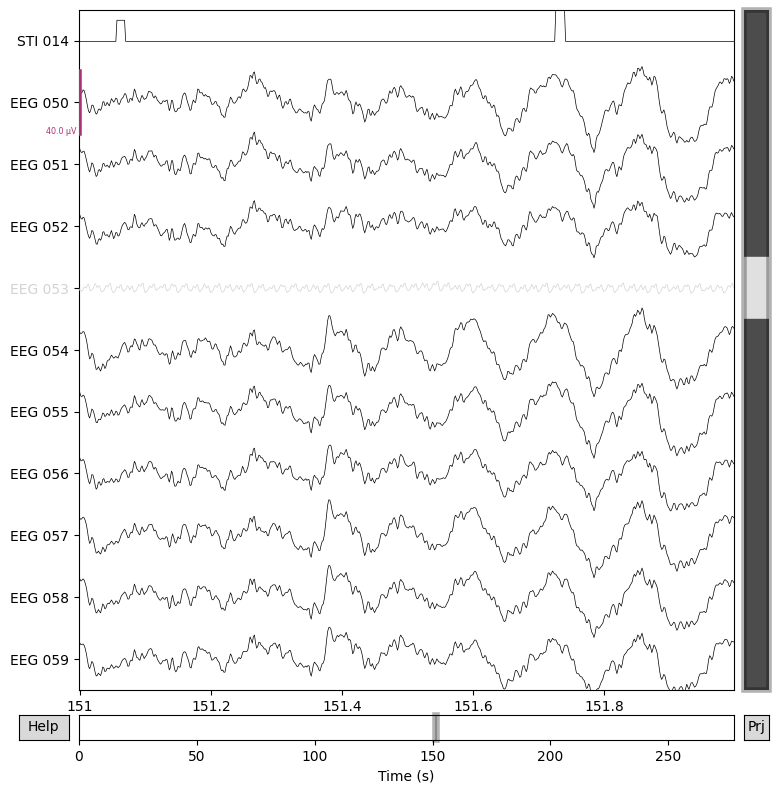

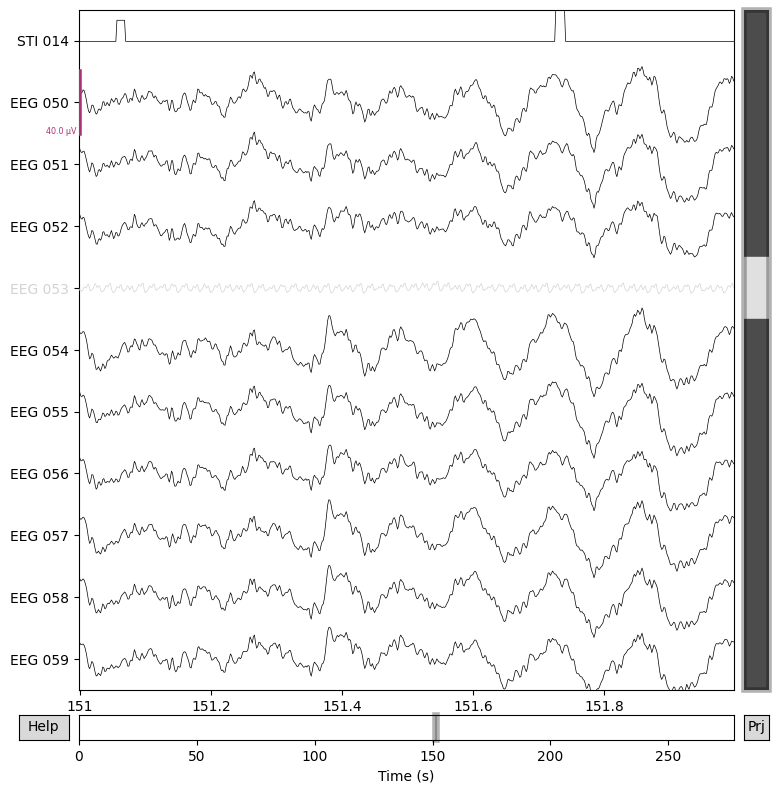

In [60]:
raw.plot(order=order, start = 151, duration = 1)

In [61]:
# TODO How many stimulus events do you observe?
# 2 Stimulus event

In [62]:
# TODO Please estimate the time between the first stimulus and brain activity response.
# First stimulus around 151.05 seconds
#EEG response starts around 151.15 seconds
# Difference 0.1 seconds which is 100ms latency

**Task 4:** Localize different brain waves for different stimuli! [35 Points]

In [63]:
# the following code groups all stimuli together
# and allows the visualization of average brain activity per stimuli.
events = mne.find_events(raw, stim_channel='STI 014')
event_dict = {'auditory/left': 1,
              'auditory/right': 2,
              'visual/left': 3,
              'visual/right': 4,
              'face': 5,
              'button': 32}

picks = mne.pick_types(raw.info, eeg=True)

epochs = mne.Epochs(raw, events, event_id=event_dict, picks=picks,
                    preload=True)

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
320 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 320 events and 421 original time points ...
0 bad epochs dropped


NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


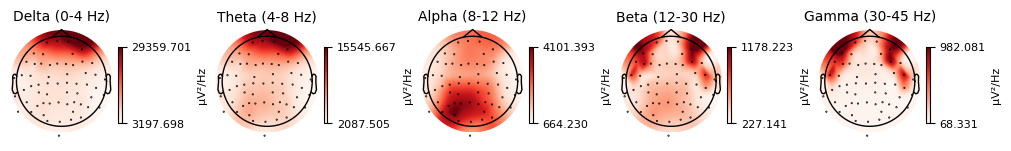

In [64]:
# here we see the average localized brain activity for the right visual stimuli
visual_activity = epochs['visual/right'].plot_psd_topomap()

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


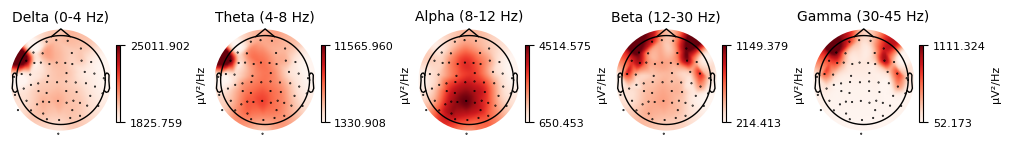

In [65]:
# here we see the average localized brain activity for the shown 'face'
face_activity = epochs['face'].plot_psd_topomap()

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


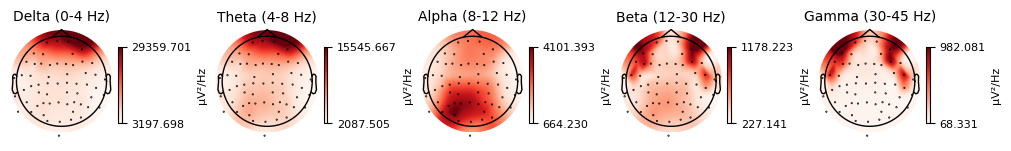

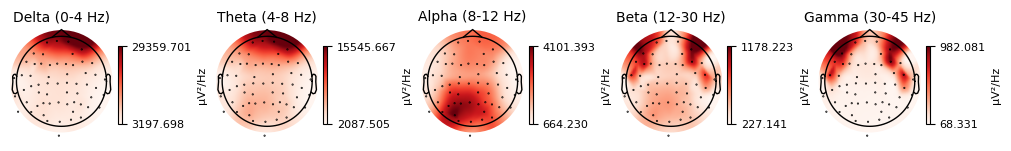

In [66]:
# TODO The above plots use a deprecated API call. Please re-create both plots here with the newer API.
epochs['visual/right'].plot_psd_topomap()

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


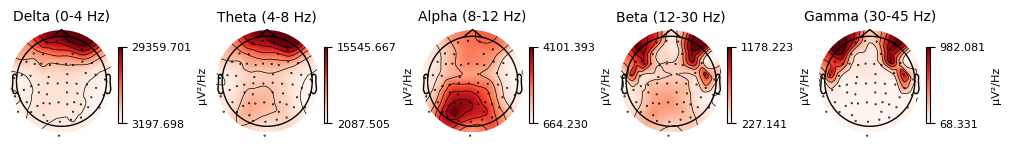

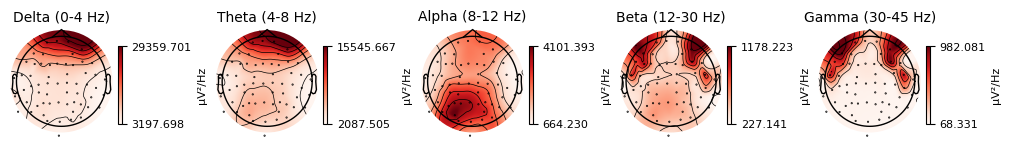

In [67]:
visual_right_spec = epochs['visual/right'].compute_psd(method="multitaper")
visual_right_spec.plot_topomap()

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


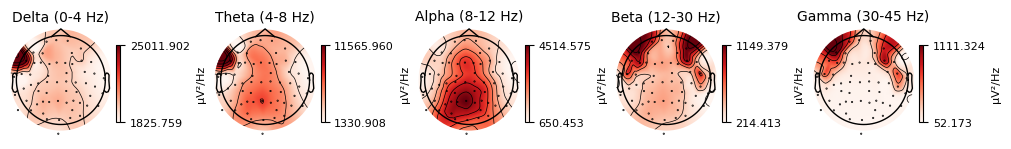

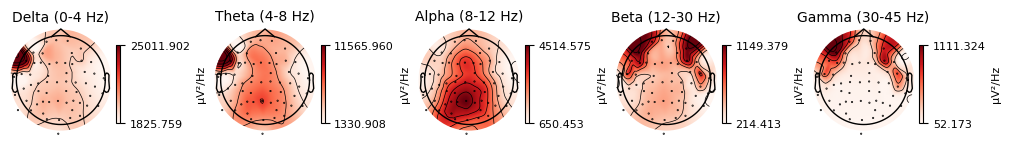

In [68]:
face_spec = epochs['face'].compute_psd(method="multitaper")
face_spec.plot_topomap()

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


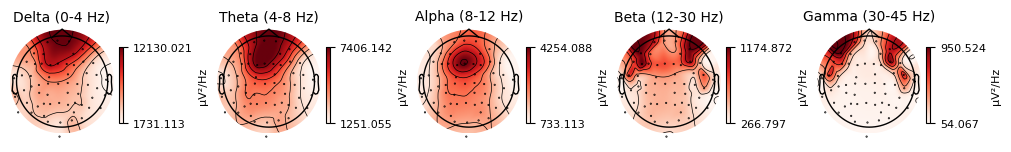

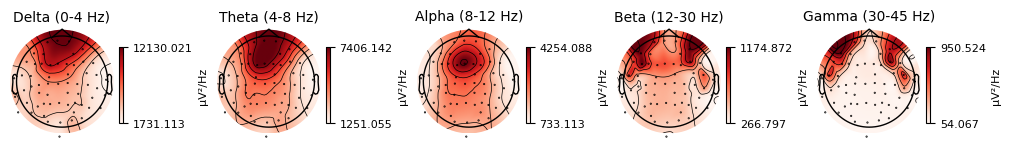

In [69]:
button_spec = epochs['button'].compute_psd(method="multitaper")
button_spec.plot_topomap()

In [70]:
# TODO Now compare the two old plots with the new ones. What are the differences?
# Very similar, new plots use updated API and smoother interpolation

In [71]:
# TODO Which difference do you see between the visual/right, the face, and the button event?
# Visual/right and face → Cortex; button → motor cortex.
# TODO Which brain region seems active during the button event?
# Motor Cortex (Central region )

**Bonus Task:** What type of event happened in Task 3? [33 Points]

In [72]:
events = mne.find_events(raw,stim_channel='STI 014')

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]


In [73]:
event_times = events[:,0]/ raw.info['sfreq']


In [74]:
events[(event_times > 151) & (event_times < 152)]

array([[90813,     0,     4],
       [91194,     0,     2]])

In [75]:
# You did it!!
#
# ┈┈┈┈┈┈▕▔╲
# ┈┈┈┈┈┈┈▏▕
# ┈┈┈┈┈┈┈▏▕▂▂▂
# ▂▂▂▂▂▂╱┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▔▔▔▔▔▔╲▂▕▂▂|
#